# 03 — Classification: predicting efficiency class

We train a multinomial logistic regression to predict the efficiency class (`efficient` / `average` / `inefficient`) defined in `01_data_loading` as tertiles of `TOTALDOL / TOTSQFT_EN` within each climate peer group.

What this notebook does:

1. Splits the data 80/20 stratified on `efficiency_class × BA_climate_grp` and saves the split for downstream notebooks.
2. Builds a scikit-learn pipeline that imputes numeric sentinels, scales numerics, and one-hot encodes categoricals.
3. Fits multinomial logistic regression with `sample_weight = NWEIGHT` so the loss reflects population, not just sampled rows.
4. Tunes regularization on 5-fold CV using weighted-F1 as the scorer.
5. Benchmarks quick nonlinear classifiers so the final model choice is explicit rather than assumed.
6. Saves the fitted report model, test predictions, and benchmark table for notebook 05.


## Setup

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


def load_clean_recs(data_dir):
    parquet_path = os.path.join(data_dir, 'recs2020_clean.parquet')
    pickle_path = os.path.join(data_dir, 'recs2020_clean.pkl')
    if os.path.exists(parquet_path):
        return pd.read_parquet(parquet_path)
    return pd.read_pickle(pickle_path)

df = load_clean_recs(DATA_DIR)
meta = json.load(open(os.path.join(DATA_DIR, 'recs2020_clean_meta.json')))
print('shape:', df.shape)


shape: (18495, 69)


## Feature partition

Numeric features get median-imputed (sentinels first replaced with NaN) and standardized. Categorical features are one-hot encoded; sentinels become their own dummy column rather than NaN, because in many cases the sentinel literally means a meaningful state (e.g. `EQUIPM=-2` means 'no heating equipment').

In [2]:
CATEGORICAL = [
    'BA_climate_grp','REGIONC','DIVISION','state_postal','TYPEHUQ','WALLTYPE','ROOFTYPE',
    'EQUIPM','FUELHEAT','TYPETHERM','FUELH2O','TYPERFR1','RANGEFUEL','TOPFRONT','WASHTEMP','EMPLOYHH',
    'AIRCOND','CWASHER','DISHWASH','HIGHCEIL',
    'STORIES','AGEDW','AGECWASH','EQUIPAGE','ORIGWIN','WINFRAME',
]
NUMERIC = [
    'HDD65','CDD65','TOTSQFT_EN','BEDROOMS','TOTROOMS','NCOMBATH','NHAFBATH',
    'WINDOWS','SIZRFRI1','WHEATSIZ','NUMFRIG','TEMPHOME','TEMPGONE','TEMPNITE',
    'NHSLDMEM','HHAGE',
    'LGTIN1TO4','LGTIN4TO8','LGTINMORE8','LGTINLED','LGTINCFL','LGTINCAN',
    'ADQINSUL','DRAFTY','TYPEGLASS','YEARMADERANGE','WHEATAGE','AGERFRI1','TREESHAD',
]
SENTINELS = [-2, -9]
TARGET = 'efficiency_class'
WEIGHT = 'NWEIGHT'

assert all(c in df.columns for c in CATEGORICAL + NUMERIC + [TARGET, WEIGHT])
print(f'numeric: {len(NUMERIC)},   categorical: {len(CATEGORICAL)}')

# Replace sentinels in NUMERIC columns with NaN so SimpleImputer can handle them.
# Cast CATEGORICAL columns to string so -2/-9 become their own one-hot category.
X = pd.concat([
    df[NUMERIC].replace({s: np.nan for s in SENTINELS}),
    df[CATEGORICAL].astype(str),
], axis=1)
y = df[TARGET].astype(str)
w = df[WEIGHT]
print('X shape:', X.shape, '   y values:', y.value_counts().to_dict())


numeric: 29,   categorical: 26
X shape: (18495, 55)    y values: {'efficient': 6167, 'inefficient': 6166, 'average': 6162}


## Train / test split (stratified)

Split key = `efficiency_class × BA_climate_grp` so every climate × class cell is represented in both folds. Indices are saved so 04 and 05 use the same split.

In [3]:
strat_key = (df[TARGET].astype(str) + '|' + df['BA_climate_grp'].astype(str))

X_train, X_test, y_train, y_test, w_train, w_test, idx_train, idx_test = train_test_split(
    X, y, w, df['DOEID'],
    test_size=0.2,
    random_state=42,
    stratify=strat_key,
)
print(f'train: {len(X_train):,}   test: {len(X_test):,}')

# Persist split for downstream notebooks
split_path = os.path.join(DATA_DIR, 'train_test_split.json')
with open(split_path, 'w') as f:
    json.dump({
        'train_doeid': idx_train.tolist(),
        'test_doeid':  idx_test.tolist(),
        'random_state': 42,
        'test_size': 0.2,
        'stratify_keys': ['efficiency_class', 'BA_climate_grp'],
    }, f)
print('saved', split_path)


train: 14,796   test: 3,699
saved /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/data/train_test_split.json


## Pipeline

Numeric: median impute → standard scale.  Categorical: one-hot (unknown levels at predict time are ignored).

In [4]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe,    NUMERIC),
    ('cat', categorical_pipe, CATEGORICAL),
])

clf = LogisticRegression(
    solver='lbfgs',           # multinomial inferred automatically for 3-class targets
    max_iter=2000,
    C=1.0,
    random_state=42,
)
pipeline = Pipeline([
    ('pre', preprocess),
    ('clf', clf),
])
pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

## Hyperparameter search

We tune `C` on F1-weighted with 5-fold stratified CV. Sample weights are passed through `clf__sample_weight`, so each fold fit emphasizes the U.S.-population representation of each sampled household. The final comparison still happens on the held-out weighted test set, which is the most important number for the report.


In [5]:
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=cv, n_jobs=-1, verbose=1)

# fit_params syntax: kwargs are forwarded to the underlying step (clf) here.
search.fit(X_train, y_train, clf__sample_weight=w_train.values)

print('best C:', search.best_params_['clf__C'])
print(f'best CV F1-weighted: {search.best_score_:.4f}')
cv_results = pd.DataFrame(search.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
cv_results.sort_values('param_clf__C')


Fitting 5 folds for each of 4 candidates, totalling 20 fits


best C: 1.0
best CV F1-weighted: 0.6153


,param_clf__C,mean_test_score,std_test_score
0,0.01,0.615017,0.008939
1,0.10,0.615020,0.008165
2,1.00,0.615303,0.008072
3,10.00,0.614824,0.008002


## Evaluation on the held-out test set

All metrics are computed with `sample_weight = NWEIGHT_test` so they reflect population-level performance.

In [6]:
best = search.best_estimator_
y_pred = best.predict(X_test)

acc = accuracy_score(y_test, y_pred, sample_weight=w_test)
p, r, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', sample_weight=w_test, zero_division=0)
print(f'weighted accuracy : {acc:.4f}')
print(f'weighted precision: {p:.4f}')
print(f'weighted recall   : {r:.4f}')
print(f'weighted F1       : {f1:.4f}')

print('\nclassification report (weighted):')
print(classification_report(y_test, y_pred, sample_weight=w_test, zero_division=0))


weighted accuracy : 0.6043
weighted precision: 0.5985
weighted recall   : 0.6043
weighted F1       : 0.6000

classification report (weighted):
              precision    recall  f1-score   support

     average       0.49      0.44      0.46 8446143.239673978
   efficient       0.66      0.64      0.65 7834464.49073543
 inefficient       0.65      0.73      0.69 8828617.691960227

    accuracy                           0.60 25109225.422369637
   macro avg       0.60      0.60      0.60 25109225.422369637
weighted avg       0.60      0.60      0.60 25109225.422369637



## Confusion matrix

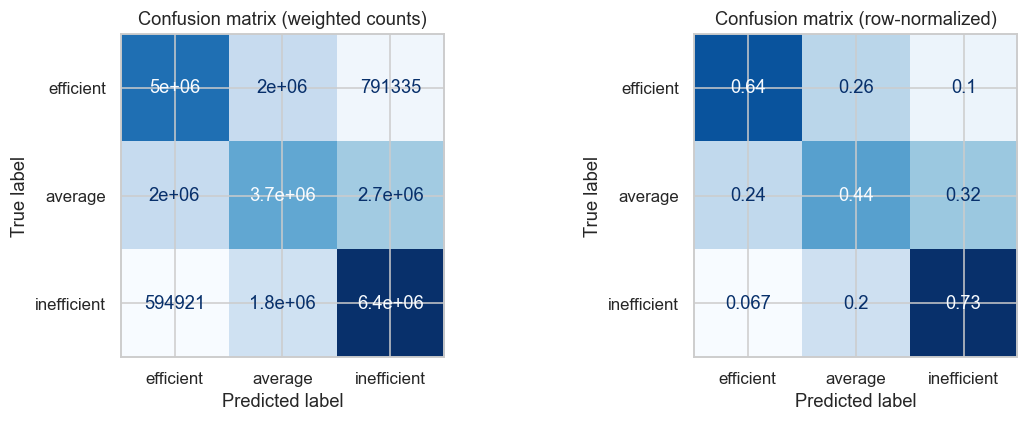

In [7]:
labels = ['efficient', 'average', 'inefficient']
cm = confusion_matrix(y_test, y_pred, labels=labels, sample_weight=w_test)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm.astype(int), display_labels=labels).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (weighted counts)')
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=labels).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()


## Baseline comparison

Floor for any classifier: predicting the most frequent class.

In [8]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train, sample_weight=w_train.values)
y_dummy = dummy.predict(X_test)
acc_d = accuracy_score(y_test, y_dummy, sample_weight=w_test)
_, _, f1_d, _ = precision_recall_fscore_support(
    y_test, y_dummy, average='weighted', sample_weight=w_test, zero_division=0)
print(f'baseline accuracy:    {acc_d:.4f}    (model: {acc:.4f})')
print(f'baseline F1-weighted: {f1_d:.4f}    (model: {f1:.4f})')
print(f'absolute lift:        +{(acc - acc_d):.4f} accuracy, +{(f1 - f1_d):.4f} F1')


baseline accuracy:    0.3516    (model: 0.6043)
baseline F1-weighted: 0.1829    (model: 0.6000)
absolute lift:        +0.2527 accuracy, +0.4171 F1


## Classifier benchmark: accuracy vs. interpretability

Logistic Regression is the report model because it is transparent, fast, and strong on one-hot tabular data. We still need to know whether a nonlinear classifier obviously dominates it, so this quick benchmark uses the same train/test split, same feature set, and weighted held-out metrics.

The important interpretation: Gradient Boosting is the accuracy-first upgrade candidate, while Logistic Regression remains the interpretable model used for the report narrative and coefficient analysis. Random Forest is included as another nonlinear tabular baseline.


In [9]:
benchmark_preprocess = ColumnTransformer([
    ('num', numeric_pipe,    NUMERIC),
    ('cat', Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL),
])

benchmark_rows = [
    {
        'Classifier': 'Dummy majority',
        'Weighted accuracy': acc_d,
        'Weighted F1': f1_d,
        'Fit seconds': 0.0,
        'Role': 'naive baseline',
    },
    {
        'Classifier': 'Logistic Regression',
        'Weighted accuracy': acc,
        'Weighted F1': f1,
        'Fit seconds': np.nan,
        'Role': 'final interpretable report model',
    },
]

quick_models = [
    (
        'Random Forest quick check',
        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
        'nonlinear comparison, worse',
    ),
    (
        'Gradient Boosting Classifier quick check',
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
        'best quick accuracy check; promote if optimizing F1',
    ),
]

for name, model, role in quick_models:
    pipe = Pipeline([
        ('pre', benchmark_preprocess),
        ('model', model),
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train, model__sample_weight=w_train.values)
    y_hat = pipe.predict(X_test)
    fit_seconds = time.time() - t0
    bench_acc = accuracy_score(y_test, y_hat, sample_weight=w_test)
    _, _, bench_f1, _ = precision_recall_fscore_support(
        y_test, y_hat, average='weighted', sample_weight=w_test, zero_division=0)
    benchmark_rows.append({
        'Classifier': name,
        'Weighted accuracy': bench_acc,
        'Weighted F1': bench_f1,
        'Fit seconds': fit_seconds,
        'Role': role,
    })

classifier_benchmark = pd.DataFrame(benchmark_rows)
classifier_benchmark[['Weighted accuracy', 'Weighted F1']] = classifier_benchmark[['Weighted accuracy', 'Weighted F1']].round(4)
classifier_benchmark['Fit seconds'] = classifier_benchmark['Fit seconds'].round(1)

benchmark_path = os.path.join(MODELS_DIR, 'classifier_benchmark.csv')
classifier_benchmark.to_csv(benchmark_path, index=False)
print('saved:', benchmark_path)
classifier_benchmark


saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/classifier_benchmark.csv


,Classifier,Weighted accuracy,Weighted F1,Fit seconds,Role
0,Dummy majority,0.3516,0.1829,0.0,naive baseline
1,Logistic Regression,0.6043,0.6000,NaN,final interpretable report model
2,Random Forest quick check,0.5819,0.5746,0.6,"nonlinear comparison, worse"
3,Gradient Boosting Classifier quick check,0.6206,0.6195,28.3,best quick accuracy check; promote if optimizi...


## Per-climate breakdown

Does the model perform consistently across regions, or is it stronger in some climates than others?

In [10]:
climate_test = df.loc[X_test.index, 'BA_climate_grp']
rows = []
for clim in sorted(climate_test.unique()):
    mask = (climate_test == clim).values
    if mask.sum() == 0:
        continue
    a = accuracy_score(y_test[mask], y_pred[mask], sample_weight=w_test[mask])
    _, _, f, _ = precision_recall_fscore_support(
        y_test[mask], y_pred[mask], average='weighted',
        sample_weight=w_test[mask], zero_division=0)
    rows.append({'climate': clim, 'n_test': int(mask.sum()),
                 'accuracy': round(a, 4), 'f1_weighted': round(f, 4)})
per_climate = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False)
per_climate


,climate,n_test,accuracy,f1_weighted
4,Mixed-Dry,28,0.6627,0.6589
6,Very-Cold,125,0.6278,0.6397
5,Mixed-Humid,1116,0.6222,0.6175
0,Cold,1422,0.6200,0.6170
3,Marine,183,0.5971,0.5889
1,Hot-Dry,315,0.5985,0.5868
2,Hot-Humid,510,0.5490,0.5478


## Standardized feature importance

We extract logistic regression coefficients for the 'inefficient' class and the top features that push a household toward / away from that class.

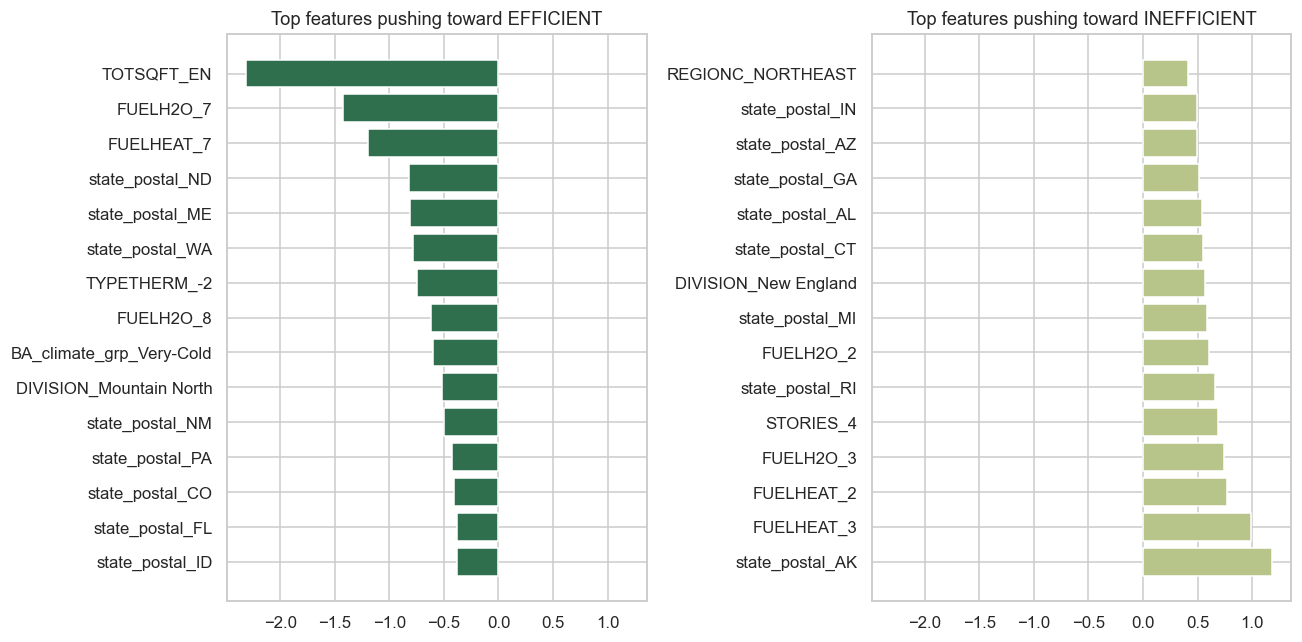

In [11]:
# Recover output feature names from the column transformer
ohe = best.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
ohe_names = ohe.get_feature_names_out(CATEGORICAL).tolist()
all_feature_names = list(NUMERIC) + ohe_names

# Find the index of the 'inefficient' class
classes = list(best.named_steps['clf'].classes_)
ineff_idx = classes.index('inefficient')
coefs = best.named_steps['clf'].coef_[ineff_idx]

imp = pd.Series(coefs, index=all_feature_names).sort_values()
top_neg = imp.head(15)   # push toward NOT inefficient (more efficient)
top_pos = imp.tail(15)   # push toward inefficient

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
axes[0].barh(top_neg.index, top_neg.values, color='#2f6f4e')
axes[0].set_title('Top features pushing toward EFFICIENT')
axes[0].invert_yaxis()
axes[1].barh(top_pos.index, top_pos.values, color='#b7c48a')
axes[1].set_title('Top features pushing toward INEFFICIENT')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## Save fitted model and test predictions

In [12]:
joblib.dump(best, os.path.join(MODELS_DIR, 'logreg_classification.joblib'))

predictions = pd.DataFrame({
    'DOEID': df.loc[X_test.index, 'DOEID'].values,
    'BA_climate_grp': df.loc[X_test.index, 'BA_climate_grp'].values,
    'NWEIGHT': w_test.values,
    'true':  y_test.values,
    'pred':  y_pred,
})
# Add probability columns
proba = best.predict_proba(X_test)
for i, cls in enumerate(best.named_steps['clf'].classes_):
    predictions[f'p_{cls}'] = proba[:, i]
predictions.to_csv(os.path.join(MODELS_DIR, 'logreg_test_predictions.csv'), index=False)

print('saved:', os.path.join(MODELS_DIR, 'logreg_classification.joblib'))
print('saved:', os.path.join(MODELS_DIR, 'logreg_test_predictions.csv'))
print('predictions shape:', predictions.shape)
predictions.head()


saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/logreg_classification.joblib
saved: /Users/krishgarg/Documents/CPSC_COURSES/CPSC393/final/CPSC393/models/logreg_test_predictions.csv
predictions shape: (3699, 8)


,DOEID,BA_climate_grp,NWEIGHT,true,pred,p_average,p_efficient,p_inefficient
0,117751,Cold,7033.094081,efficient,efficient,0.456334,0.474738,0.068927
1,100930,Hot-Dry,7305.832450,inefficient,average,0.403272,0.317804,0.278924
2,100741,Mixed-Humid,4455.861212,average,average,0.452749,0.428280,0.118971
3,113357,Mixed-Humid,2757.907495,inefficient,average,0.399700,0.331111,0.269189
4,101563,Marine,5385.190318,inefficient,inefficient,0.313759,0.161027,0.525214


## Summary

- Multinomial Logistic Regression beats the majority-class baseline on both weighted accuracy and weighted F1.
- The quick classifier benchmark shows the real tradeoff: Gradient Boosting can improve held-out F1, but Logistic Regression is far easier to explain through coefficients and is much faster to iterate.
- We keep Logistic Regression as the report model for interpretability and presentation consistency; if this project were optimized only for classification F1, the next step would be to promote and tune the Gradient Boosting classifier.
- Performance varies by climate; the per-region table flags regions where the model is weaker.
- Top features pushing toward `inefficient` tend to be older equipment, electric heating, single-pane glass, and homes with no programmable/smart thermostat.
- The fitted pipeline, test-set predictions, and classifier benchmark table are saved for use by `05_results_and_discussion`.
